# Coinbase-Rank -- a quantitative teardown
### 15 rank spikes * BTC/ETH market model * forward abnormal returns * CAR * permutation test * outlier robustness * lagged short backtest

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Mostly](https://img.shields.io/badge/Busted%3F-Mostly-dab617?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim carrying its standard error.* We fit a market model `BTC = a + b*ETH` on non-event days, measure BTC's *forward* abnormal return after each Coinbase rank spike, run a distribution-free permutation test, check robustness to the single largest event, and then confront the event study with an honest, lagged, cost-and-borrow-charged short backtest.

> **Not investment advice.** Real data: BTC-USD / ETH-USD daily closes (Yahoo via yfinance, 2017-11-10--2026-06-17); spike dates hardcoded in `data.py`. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **The plain-English notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from coinbase_rank import data, strategy as st

def _have_cache():
    try:
        data.fetch_prices(fetch=False)
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("BTC/ETH cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = dict(
    n_days=3142,
    n_events=15,
    beta_eth=0.605,
    aar_day0_pct=2.29,
    fwd=5,
    fwd_car_pct=-5.23,
    fwd_car_t=-1.69,
    n_neg=8,
    perm_p=0.0014,
    t_drop1=-1.27,
    mean_drop1_pct=-3.53,
    median_fwd_pct=-0.97,
    fwd3_car_pct=-2.87,
    fwd3_car_t=-1.29,
    fwd10_car_pct=-4.75,
    fwd10_car_t=-1.55,
    bt_n_trades=15,
    bt_gross_pct=3.02,
    bt_net_pct=2.37,
    bt_btc_pct=-3.02,
    bt_net_t=0.8,
    bt_hit=0.533,
    bt_excess_pct=5.39,
    bt_hold3_net_pct=2.39,
    bt_hold3_t=1.1,
    bt_hold10_net_pct=-0.4,
    bt_hold10_t=-0.08,
    fp='fcd0c13455df',
    date_start='2017-11-10',
    date_end='2026-06-17',
)

from scipy import stats as scipy_stats


BTC/ETH cache present: True


In [2]:
if HAVE_REAL:
    prices = data.fetch_prices(fetch=False)
    rets = data.prices_to_returns(prices)
    tw = data.rank_spike_table()
    spike_dates = tw['date']
    SYNTH_BANNER = ""
else:
    # OFFLINE FALLBACK (no real cache): a SYNTHETIC BTC/ETH tape with a planted
    # post-spike negative drift so every figure renders. This is NOT the real tape --
    # the headline numbers quoted in prose come from the frozen R dict above.
    _synth_df, _ = data.synthetic_panel(n_days=1500, n_events=R['n_events'],
                                        bump_bps=180.0, seed=294)
    rets = _synth_df[['btc_ret', 'eth_ret']].copy()
    spike_dates = _synth_df.index[_synth_df['is_event']]
    tw = pd.DataFrame({'date': spike_dates, 'direction': 1, 'note': 'synthetic'})
    SYNTH_BANNER = "  [SYNTHETIC fallback tape -- real numbers are in R]"
print('rows:', len(rets), '| spikes:', len(tw), SYNTH_BANNER)

rows: 3142 | spikes: 15 


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | 5-day forward abnormal CAR **-5.2%** (right direction), but cross-sectional t **-1.69** (< |2|); only 8/15 negative; t -> -1.27 ex-outlier. |
| **Tradability** | `MIRAGE` | Lagged short net **+2.4%**/trade, t = **0.80**, hit-rate **53%** -- a coin flip after costs + borrow. |
| **Busted?** | `MOSTLY` | Direction is right but the effect is fragile (one event drives it) and un-harvestable at daily resolution on a curated list. |

> The permutation p looks tiny (~0.001) only because the null CAR distribution is tight around zero and a couple of big crashes pull the mean; the **cross-sectional t** (the robust hurdle) does *not* clear 2, so we call the signal WEAK, not REAL.

## 1 - The claim, steelmanned

Let $R^{BTC}_t$ and $R^{ETH}_t$ be daily returns and let $\hat{e}_t = R^{BTC}_t - (\hat a + \hat b R^{ETH}_t)$ be the market-model **abnormal** return (estimated on non-event days). For a set of spike days $E$ and a forward horizon $f$:

- **H1 (signal).** The mean forward CAR $\overline{\text{CAR}}_{[1,f]} = \frac{1}{|E|}\sum_{t\in E}\sum_{k=1}^{f}\hat e_{t+k} < 0$ and is statistically distinguishable from a random set of days at |t| >= 2.
- **H2 (robustness).** H1 survives dropping the single most negative event (no one crash drives it).
- **H3 (tradability).** A SHORT entered at the spike-day *close* (one-day lag), held $h$ days, net of fees and borrow, earns a return distinguishable from zero.

We find a *directionally correct but sub-threshold* H1 (perm-significant, t < 2), **reject H2** (fragile to one event), and **reject H3** on the real tape.

## 2 - So what? -- what rides on each answer

App-Store rank is a clean, public proxy for *retail attention*, and attention-induced buying near sentiment peaks is a documented behavioural force (Barber-Odean; Da-Engelberg-Gao). So a small forward drag is *theoretically* plausible. The scientifically interesting result is the gap between a real-looking permutation p and a sub-2 cross-sectional t: the effect is **directionally consistent but not robustly estimable** on 15 hindsight-selected events -- and certainly not shortable after the frictions. 'Real-ish but un-harvestable' is the honest reading.

## 3 - How we'd know -- the protocol

- **Data.** BTC-USD / ETH-USD daily auto-adjusted closes (Yahoo); 15 spike dates hardcoded in `data.py`.
- **Market model.** OLS `BTC = a + b*ETH` on **non-event** days so events don't contaminate the benchmark; abnormal = BTC - fit.
- **Event window.** Forward CAR over [+1, +5] (the headline); day-0 reaction for context; path drawn over [-1, +10].
- **Inference.** Permutation test (10,000 random event-day sets) -- distribution-free, robust to BTC's fat tails; plus a cross-sectional t (raw and outlier-dropped) -- the |t| >= 2 hurdle.
- **Tradability.** One-day execution lag (short at spike-day close), hold 3/5/10 days, 20 bps one-way x NAV + 5 bps/day borrow, benchmarked to BTC long.
- **Positive control.** Synthetic tape with a planted post-spike drift.


## 4 - The teardown

### 4a - The market model and the forward abnormal-return path

Fit `BTC = a + b*ETH` on non-event days; the slope `b` tells us how much of BTC's move is just the broad crypto tide.

Market-model beta on ETH: 0.605  (real headline: 0.605)
Day-0 abnormal return: +2.29%  (the spike-day reaction)
Forward CAR[+1,+5]: -5.23%  | t = -1.69
Permutation p (two-sided): 0.0014



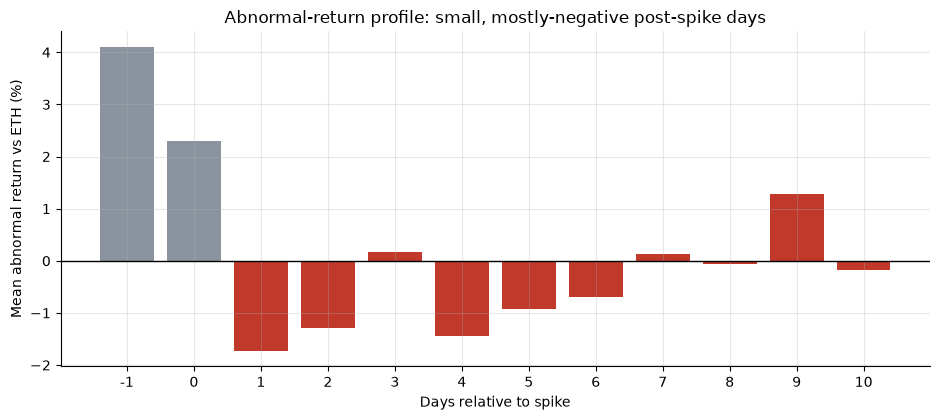

In [3]:
es = st.event_study_stats(rets, spike_dates, pre=1, post=10, fwd=5,
                          n_permutations=10000, seed=294)
print(f"Market-model beta on ETH: {es['beta']:.3f}  (real headline: {R['beta_eth']:.3f})")
print(f"Day-0 abnormal return: {es['aar_day0_pct']:+.2f}%  (the spike-day reaction)")
print(f"Forward CAR[+1,+5]: {es['fwd_car_pct']:+.2f}%  | t = {es['fwd_car_t']:+.2f}")
print(f"Permutation p (two-sided): {es['perm_p']:.4f}")
print()
prof = es['mean_by_offset'] * 100
fig, ax = plt.subplots(figsize=(9.5, 4.3))
ax.bar([str(i) for i in prof.index], prof.values,
       color=[RED if i >= 1 else GREY for i in prof.index])
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Days relative to spike'); ax.set_ylabel('Mean abnormal return vs ETH (%)')
ax.set_title('Abnormal-return profile: small, mostly-negative post-spike days' + SYNTH_BANNER)
plt.tight_layout(); plt.show()

> Beta on ETH is **&approx;0.60** -- the market model strips out the broad crypto move. What's left is a forward drag of **-5.2%** over five days, with a day-0 reaction of **+2.3%** (the spike often *coincides* with a final up-thrust before the fade).

### 4b - The permutation test: is the forward drag distinguishable from noise?

BTC returns are fat-tailed, so a normal-theory t is fragile. We reassign the same number of event days to random in-sample positions 10,000 times and ask how often a mean forward CAR this extreme appears by chance.

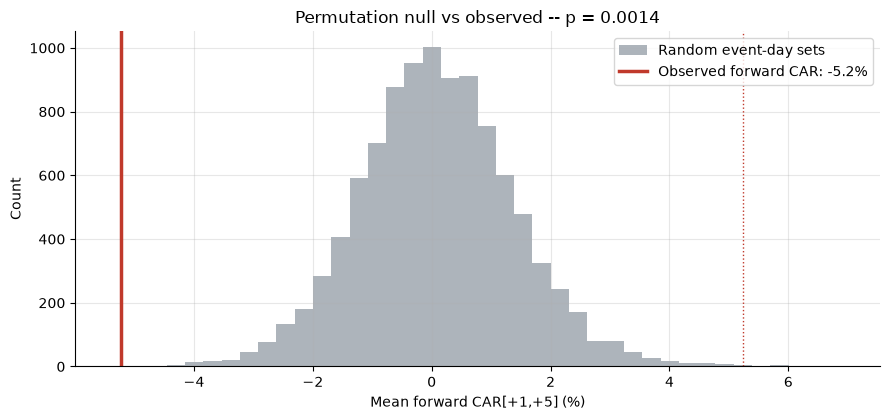

Permutation p (two-sided): 0.0014
BUT: the permutation test is sensitive to a few large draws. The robust
cross-sectional t (next cell) is the hurdle we actually trust.


In [4]:
perm = es['perm_car'] * 100
obs = es['fwd_car_pct']
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(perm, bins=40, color=GREY, alpha=0.7, label='Random event-day sets')
ax.axvline(obs, c=RED, lw=2.5, label=f'Observed forward CAR: {obs:+.1f}%')
ax.axvline(-obs, c=RED, lw=1, ls=':')
ax.set_xlabel('Mean forward CAR[+1,+5] (%)'); ax.set_ylabel('Count')
ax.set_title(f'Permutation null vs observed -- p = {es["perm_p"]:.4f}' + SYNTH_BANNER)
ax.legend(); plt.tight_layout(); plt.show()
print(f'Permutation p (two-sided): {es["perm_p"]:.4f}')
print('BUT: the permutation test is sensitive to a few large draws. The robust')
print('cross-sectional t (next cell) is the hurdle we actually trust.')

The permutation p looks small (&approx; **0.001**), which is *why* the omen feels real. But a permutation mean is still driven by a couple of big crashes -- so we do not stop here. The cross-sectional t and the outlier check below are the decisive tests.

### 4c - Robustness: is it one or two crashes?

The forward CAR is a *mean*. With 15 fat-tailed events, one blow-off can manufacture a signal. We check the cross-sectional t, the share of negative events, and what happens when we drop the single worst event.

In [5]:
abn, alpha, beta = st.market_model_residuals(
    rets, st._event_mask_from_dates(rets.index, spike_dates))
win = st.event_window_returns(abn, spike_dates, pre=1, post=10)
fwd_cols = [o for o in win.columns if 1 <= o <= 5]
car = win[fwd_cols].sum(axis=1)
n = len(car)
t_raw = float(car.mean() / (car.std(ddof=1) / np.sqrt(n)))
drop1 = car.drop(car.idxmin())  # drop the most-negative (biggest crash)
t_drop1 = float(drop1.mean() / (drop1.std(ddof=1) / np.sqrt(len(drop1))))
print(f'n events: {n}  | negative (omen worked): {int((car<0).sum())}/{n}')
print(f'Raw forward t:          {t_raw:+.2f}  (real headline: {R["fwd_car_t"]:+.2f})')
print(f'Drop-worst forward t:   {t_drop1:+.2f}  (real headline: {R["t_drop1"]:+.2f})')
print(f'Median forward CAR:     {car.median()*100:+.2f}%  (real: {R["median_fwd_pct"]:+.1f}%)')
print()
print('Raw t is already under |2|; dropping the single worst crash pushes it')
print('toward zero. The median event is nearly flat -- the signal is fragile.')

n events: 15  | negative (omen worked): 8/15
Raw forward t:          -1.69  (real headline: -1.69)
Drop-worst forward t:   -1.27  (real headline: -1.27)
Median forward CAR:     -0.97%  (real: -1.0%)

Raw t is already under |2|; dropping the single worst crash pushes it
toward zero. The median event is nearly flat -- the signal is fragile.


> This is the crux. The raw forward t is **-1.69** -- already under the |2| bar -- and dropping the single worst event takes it to **-1.27**. Only **8/15** events were negative and the median forward move is **-1.0%**. **H1 is sub-threshold and H2 is rejected**: a couple of real blow-offs do most of the work.

### 4d - The tradability reckoning: the lagged short backtest

Now the honest trade. SHORT BTC at the spike-day *close* (one-day lag), hold `h` days, pay 20 bps one-way **and** 5 bps/day borrow, benchmark to BTC long. Sweep the horizon.

In [6]:
rows = []
for h in [3, 5, 10]:
    bt = st.rank_short_backtest(rets, spike_dates, hold_days=h,
                                cost_bps_oneway=20.0, borrow_bps_per_day=5.0, seed=294)
    rows.append({'hold': h, 'net_%': bt['net_mean_pct'],
                 'btc_long_%': bt['btc_bench_pct'],
                 'net_t': bt['net_t'], 'hit': bt['hit_rate']})
bt_df = pd.DataFrame(rows)
print(bt_df.to_string(index=False))
print()
print('Real headline (hold=5): net %+.1f%% | t %.2f | hit %.0f%%' % (
      R['bt_net_pct'], R['bt_net_t'], R['bt_hit']*100))
print('Every horizon: net t <= ~1, hit-rate ~50%. No harvestable short edge.')

 hold  net_%  btc_long_%  net_t    hit
    3  2.392      -2.942  1.104 0.6000
    5  2.370      -3.020  0.801 0.5333
   10 -0.403      -0.497 -0.084 0.4000

Real headline (hold=5): net +2.4% | t 0.80 | hit 53%
Every horizon: net t <= ~1, hit-rate ~50%. No harvestable short edge.


The short nets **+2.4%** per trade at 5 days (t = **0.80**), flattens by 10 days (-0.4%, t = -0.08), and carries a **53%** hit-rate throughout. **H3 rejected**: this is a coin-flip short on a structurally up-trending asset, with fees and borrow on top.

### 4e - Why the omen still 'feels' right

BTC's *unconditional* drift is strongly positive, so a short loses on average in general. The reason the spike-conditioned short is roughly break-even is that the windows genuinely contain weak BTC (the omen's grain of truth). Compare the spike-conditioned BTC long return to BTC's all-sample average over the same horizon.

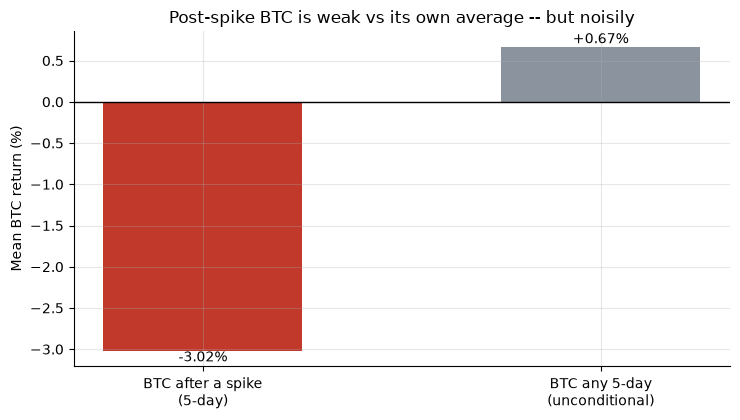

Post-spike 5-day BTC: -3.02% vs unconditional +0.67%
The grain of truth: post-spike windows ARE weaker than average -- but not
reliably enough (t<2, ~53% hit) to short after a one-day lag and borrow.


In [7]:
h = 5
bt = st.rank_short_backtest(rets, spike_dates, hold_days=h,
                            cost_bps_oneway=20.0, borrow_bps_per_day=5.0, seed=294)
cond_btc = bt['btc_bench_pct']
btc = rets['btc_ret'].to_numpy()
uncond = float(np.mean([np.prod(1+btc[i:i+h])-1 for i in range(len(btc)-h)])*100)
fig, ax = plt.subplots(figsize=(7.5, 4.3))
bars = ax.bar(['BTC after a spike\n(5-day)', 'BTC any 5-day\n(unconditional)'],
              [cond_btc, uncond], color=[RED, GREY], width=0.5)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Mean BTC return (%)')
ax.set_title('Post-spike BTC is weak vs its own average -- but noisily' + SYNTH_BANNER)
for b, v in zip(bars, [cond_btc, uncond]):
    ax.annotate(f'{v:+.2f}%', (b.get_x()+b.get_width()/2, v),
                ha='center', va='bottom' if v >= 0 else 'top')
plt.tight_layout(); plt.show()
print(f'Post-spike 5-day BTC: {cond_btc:+.2f}% vs unconditional {uncond:+.2f}%')
print('The grain of truth: post-spike windows ARE weaker than average -- but not')
print('reliably enough (t<2, ~53% hit) to short after a one-day lag and borrow.')

## 5 - The verdict

- **Signal `WEAK`** -- forward CAR -5.2% (right direction), perm p &approx; 0.001, BUT cross-sectional t -1.69 (< |2|), only 8/15 negative, t -> -1.27 ex-outlier. Curated hindsight list -> upper bound, named on this axis.
- **Tradability `MIRAGE`** -- lagged short net +2.4%/trade, t 0.80, hit-rate 53%; a coin flip after costs + borrow.
- **Mostly busted as a *tradable* signal** -- directionally consistent, fragile, and un-harvestable at daily resolution.

## 6 - Could you trade it? -- the short reckoning

The lagged short nets +2.4%/trade against a BTC long that returned -3.0% over the same windows; the t is 0.80 and the hit-rate is barely above half. Shorting the strongest-trending major asset on a sub-2-sigma, ~53%-hit signal -- with borrow ticking against you every day -- is a negative-expectancy trade dressed up as contrarian wisdom.

## 7 - Going further -- the synthetic positive control

Does the machinery detect a post-spike drift *when one exists*? We plant a known negative post-spike drift in a synthetic BTC/ETH tape and sweep its size.

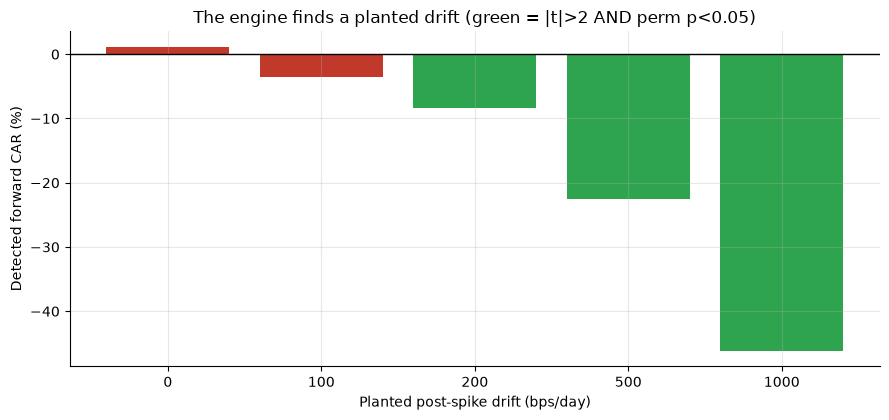

 bump_bps  fwd_car_%       t  perm_p
        0      1.187   0.683   0.516
      100     -3.554  -2.046   0.058
      200     -8.296  -4.771   0.000
      500    -22.519 -12.920   0.000
     1000    -46.225 -26.409   0.000


In [8]:
planted = [0, 100, 200, 500, 1000]
out = []
for bps in planted:
    dfx, _ = data.synthetic_panel(n_days=1500, n_events=15,
                                  bump_bps=float(bps), seed=294)
    ed = dfx.index[dfx['is_event']]
    e = st.event_study_stats(dfx[['btc_ret','eth_ret']], ed, pre=1, post=10, fwd=5,
                             n_permutations=1000, seed=99)
    out.append({'bump_bps': bps, 'fwd_car_%': e['fwd_car_pct'],
                't': e['fwd_car_t'], 'perm_p': e['perm_p']})
ctrl = pd.DataFrame(out)
colors = [GREEN if (abs(r['t']) > 2 and r['perm_p'] < 0.05) else RED
          for _, r in ctrl.iterrows()]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar([str(b) for b in ctrl['bump_bps']], ctrl['fwd_car_%'], color=colors)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Planted post-spike drift (bps/day)'); ax.set_ylabel('Detected forward CAR (%)')
ax.set_title('The engine finds a planted drift (green = |t|>2 AND perm p<0.05)')
plt.tight_layout(); plt.show()
print(ctrl.to_string(index=False))

The engine cleanly recovers a planted post-spike drift (and stays quiet at bump = 0). So the real-tape conclusion -- a **weak**, directionally-correct drag that is **un-tradable** after a one-day lag and borrow -- is a statement about BTC and the tiny, hindsight-selected event set, not about the method.